# PINN -> CSV for Will's drive

Runs your trained grey-box PINN on Will's `vehicle_sensors.txt` over the GNSS outage and writes the predicted **(t, x, y)** to a CSV, ready to feed into Will's MATLAB filter.

The (x, y) are **start-relative** (they begin at 0,0); anchoring to Will's map happens later in MATLAB.


## 1. Config


In [12]:
# ===== CONFIG -- edit these =====
# Will's recording: upload BOTH files to this Kaggle notebook, then point these at them.
VEHICLE_SENSORS = '/kaggle/input/datasets/aminemoussi1/wills-records/vehicle_sensors.txt'   # Will's ExampleFileStructure file
GROUND_TRUTH    = '/kaggle/input/datasets/aminemoussi1/wills-records/vehicle_sensors.txt'      # Will's (used only for the sanity plot)

# Your TRAINED model: point at pinn_round_big.pt (your 6.07 m model), NOT the old synthetic-only one.
MODEL_PATH = '/kaggle/input/models/aminemoussi1/pinn-v1/pytorch/default/1/pinn_round_big.pt'

OUTAGE     = (4.25, 33.0)   # outage window in seconds (same window as Will's filter)
DT_PHYS    = 0.00825        # recording tick rate (121 Hz)
DT         = 0.1            # PINN rate (10 Hz)
INTEGRATOR = 'closed_form'  # your v7 winner
SEED       = 0              # which noise realization to export (change for a different draw)
OUT_CSV    = '/kaggle/working/pinn_xy_will.csv'
print('config OK')


config OK


## 2. Imports + model definition (copied from your notebook)


In [13]:
import os, numpy as np, torch
import torch.nn as nn
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)


device: cpu


In [14]:
class BiasGRU(nn.Module):
    def __init__(self, hidden=32, n_layers=1):
        super().__init__()
        self.gru  = nn.GRU(input_size=6, hidden_size=hidden,
                           num_layers=n_layers, batch_first=True)
        self.head = nn.Linear(hidden, 2)
        # Small (NOT zero) weights so initial bias predictions are tiny
        # but gradients can flow back into the GRU.
        nn.init.normal_(self.head.weight, std=1e-3)
        nn.init.zeros_(self.head.bias)

    def forward(self, imu_seq, state_seq):
        x = torch.cat([imu_seq, state_seq], dim=-1)
        h, _ = self.gru(x)
        bias = self.head(h)
        return bias


class GreyBoxPINN(nn.Module):
    def __init__(self, hidden=32, integrator='euler'):
        super().__init__()
        self.bias_net = BiasGRU(hidden=hidden)
        self.integrator = integrator

    def forward(self, ax, ay, wz, dt, v0, yaw0):
        B, T = ax.shape
        v0_seq     = v0.unsqueeze(1).expand(B, T)
        sin_yaw0_s = torch.sin(yaw0).unsqueeze(1).expand(B, T)
        cos_yaw0_s = torch.cos(yaw0).unsqueeze(1).expand(B, T)
        imu_seq    = torch.stack([ax, ay, wz], dim=-1)
        state_seq  = torch.stack([v0_seq, sin_yaw0_s, cos_yaw0_s], dim=-1)
        bias_seq   = self.bias_net(imu_seq, state_seq)

        x_list   = [torch.zeros(B, device=ax.device)]
        y_list   = [torch.zeros(B, device=ax.device)]
        v_list   = [v0]
        yaw_list = [yaw0]
        eps = 1e-4

        for i in range(T - 1):
            b_a = bias_seq[:, i, 0]; b_w = bias_seq[:, i, 1]
            ax_clean = ax[:, i] - b_a
            wz_clean = wz[:, i] - b_w
            dt_i  = dt[:, i]
            v_cur = v_list[-1]; psi = yaw_list[-1]

            if self.integrator == 'euler':
                x_next = x_list[-1] + v_cur * torch.cos(psi) * dt_i
                y_next = y_list[-1] + v_cur * torch.sin(psi) * dt_i
            elif self.integrator == 'closed_form':
                psi_new = psi + wz_clean * dt_i
                mask    = torch.abs(wz_clean) < eps
                safe_w  = torch.where(mask, torch.full_like(wz_clean, eps), wz_clean)
                x_cf = x_list[-1] + v_cur * (torch.sin(psi_new) - torch.sin(psi)) / safe_w
                y_cf = y_list[-1] - v_cur * (torch.cos(psi_new) - torch.cos(psi)) / safe_w
                x_st = x_list[-1] + v_cur * torch.cos(psi) * dt_i
                y_st = y_list[-1] + v_cur * torch.sin(psi) * dt_i
                x_next = torch.where(mask, x_st, x_cf)
                y_next = torch.where(mask, y_st, y_cf)
            elif self.integrator == 'rk4':
                a = ax_clean; w = wz_clean
                def _d(xx, yy, vv, pp):
                    return vv*torch.cos(pp), vv*torch.sin(pp), a, w
                k1 = _d(x_list[-1], y_list[-1], v_cur, psi)
                k2 = _d(x_list[-1]+0.5*dt_i*k1[0], y_list[-1]+0.5*dt_i*k1[1], v_cur+0.5*dt_i*k1[2], psi+0.5*dt_i*k1[3])
                k3 = _d(x_list[-1]+0.5*dt_i*k2[0], y_list[-1]+0.5*dt_i*k2[1], v_cur+0.5*dt_i*k2[2], psi+0.5*dt_i*k2[3])
                k4 = _d(x_list[-1]+dt_i*k3[0],     y_list[-1]+dt_i*k3[1],     v_cur+dt_i*k3[2],     psi+dt_i*k3[3])
                x_next = x_list[-1] + dt_i/6.0*(k1[0]+2*k2[0]+2*k3[0]+k4[0])
                y_next = y_list[-1] + dt_i/6.0*(k1[1]+2*k2[1]+2*k3[1]+k4[1])
            else:
                raise ValueError(self.integrator)

            v_next   = v_cur + ax_clean * dt_i
            yaw_next = psi   + wz_clean * dt_i
            x_list.append(x_next); y_list.append(y_next)
            v_list.append(v_next); yaw_list.append(yaw_next)

        x   = torch.stack(x_list,   dim=1)
        y   = torch.stack(y_list,   dim=1)
        v   = torch.stack(v_list,   dim=1)
        yaw = torch.stack(yaw_list, dim=1)
        return x, y, v, yaw, bias_seq

In [15]:
NOISE_PARAMS_C = dict(
    sigma_b0_a=0.10,
    sigma_b0_w=0.015,
    sigma_a=0.05,          # white noise on accel (m/s²)
    sigma_w=0.01,          # white noise on gyro  (rad/s)
    sigma_brwa=0.001,      # accel bias random walk (m/s²/√s)
    sigma_brww=0.0002,     # gyro bias random walk  (rad/s/√s)
)

def inject_full_noise(window, noise_params, seed):
    """Constant bias + white noise + bias random walk."""
    rng = np.random.default_rng(seed)
    N = len(window['t'])
    dt = float(window['dt'][0])
    b0_ax = rng.normal(0.0, noise_params['sigma_b0_a'])
    b0_wz = rng.normal(0.0, noise_params['sigma_b0_w'])
    white_ax = rng.normal(0.0, noise_params['sigma_a'], N)
    white_wz = rng.normal(0.0, noise_params['sigma_w'], N)
    brw_ax = np.cumsum(rng.normal(0.0, noise_params['sigma_brwa']*np.sqrt(dt), N))
    brw_wz = np.cumsum(rng.normal(0.0, noise_params['sigma_brww']*np.sqrt(dt), N))
    bias_a_profile = b0_ax + brw_ax
    bias_w_profile = b0_wz + brw_wz
    return {
        'ax': window['ax'] + bias_a_profile + white_ax,
        'ay': window['ay'],
        'wz': window['wz'] + bias_w_profile + white_wz,
        'bias_a_profile': bias_a_profile,
        'bias_w_profile': bias_w_profile,
    }


def stack_batch_full_noise_v2(windows, noise_params, base_seed):
    """Same as stack_batch_full_noise but also returns per-timestep bias profiles."""
    noisy = [inject_full_noise(w, noise_params, base_seed + i) for i, w in enumerate(windows)]
    ax = torch.tensor(np.stack([n['ax'] for n in noisy]), dtype=torch.float32, device=DEVICE)
    ay = torch.tensor(np.stack([n['ay'] for n in noisy]), dtype=torch.float32, device=DEVICE)
    wz = torch.tensor(np.stack([n['wz'] for n in noisy]), dtype=torch.float32, device=DEVICE)
    dt = torch.tensor(np.stack([w['dt'] for w in windows]), dtype=torch.float32, device=DEVICE)
    v0 = torch.tensor([w['v0']   for w in windows], dtype=torch.float32, device=DEVICE)
    yaw0 = torch.tensor([w['yaw0'] for w in windows], dtype=torch.float32, device=DEVICE)
    b_a_mean = torch.tensor([n['bias_a_profile'].mean() for n in noisy],
                            dtype=torch.float32, device=DEVICE)
    b_w_mean = torch.tensor([n['bias_w_profile'].mean() for n in noisy],
                            dtype=torch.float32, device=DEVICE)
    # NEW: per-timestep bias profile tensors (B, T)
    ba_profile = torch.tensor(np.stack([n['bias_a_profile'] for n in noisy]),
                              dtype=torch.float32, device=DEVICE)
    bw_profile = torch.tensor(np.stack([n['bias_w_profile'] for n in noisy]),
                              dtype=torch.float32, device=DEVICE)
    return ax, ay, wz, dt, v0, yaw0, b_a_mean, b_w_mean, ba_profile, bw_profile

## 3. Load your trained PINN


In [16]:
model = GreyBoxPINN(integrator=INTEGRATOR).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print('loaded model:', MODEL_PATH)


loaded model: /kaggle/input/models/aminemoussi1/pinn-v1/pytorch/default/1/pinn_round_big.pt


## 4. Build the noisy IMU from Will's speed + yaw, over the outage


In [17]:
import numpy as np

def parse_pairs(path, n):
    rows = []
    for line in open(path):
        p = [s.strip() for s in line.strip().split(",")]
        if len(p) < 2 * n:
            continue
        try:
            rows.append([float(p[2 * i + 1]) for i in range(n)])
        except ValueError:
            continue
    return np.array(rows)

def smooth(a, w=5):
    pad = w // 2
    return np.convolve(np.pad(a, pad, mode="edge"), np.ones(w) / w, mode="valid")

# derive clean IMU + speed/yaw + true path from the raw recording, all on a 10 Hz grid
veh = parse_pairs(VEHICLE_SENSORS, 3)            # steer, speed, yaw(deg)
gt  = parse_pairs(GROUND_TRUTH, 3)               # x, y, z
t_p  = np.arange(len(veh)) * DT_PHYS
t_gt = np.arange(len(gt)) * DT_PHYS

t   = np.arange(t_p[0], t_p[-1], DT)
spd = smooth(np.interp(t, t_p, veh[:, 1]))
yaw = smooth(np.interp(t, t_p, np.unwrap(np.deg2rad(veh[:, 2]))))
ax_c = np.gradient(spd, DT)
wz_c = np.gradient(yaw, DT)
ay_c = spd * wz_c
gx = np.interp(t, t_gt, gt[:, 0]); gy = np.interp(t, t_gt, gt[:, 1])

i0, i1 = int(np.searchsorted(t, OUTAGE[0])), int(np.searchsorted(t, OUTAGE[1]))
sl = slice(i0, i1 + 1)
t_o = t[sl]; N = len(t_o)
v0, yaw0 = float(spd[i0]), float(yaw[i0])
xg = gx[sl] - gx[i0]; yg = gy[sl] - gy[i0]       # true path relative to the dropout point

carla = dict(t=t_o, dt=np.full(N, DT), ax=ax_c[sl], ay=ay_c[sl], wz=wz_c[sl],
             v0=v0, yaw0=yaw0, x_gt=xg, y_gt=yg)
print("outage window: %d samples (%.1f s), v0=%.1f m/s, yaw0=%.0f deg"
      % (N, t_o[-1] - t_o[0], v0, np.degrees(yaw0)))


outage window: 288 samples (28.7 s), v0=4.0 m/s, yaw0=-179 deg


## 5. Run the PINN and export the CSV


In [18]:
# Run the PINN on Will's drive (one noise realization) and export (t, x, y) to CSV.
def run_pinn(ax, ay, wz, v0, yaw0, dt):
    A = lambda a: torch.tensor(a[None, :], dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        xp, yp, _, _, bias = model(A(ax), A(ay), A(wz), A(np.full(len(ax), dt)),
                                   torch.tensor([v0], dtype=torch.float32, device=DEVICE),
                                   torch.tensor([yaw0], dtype=torch.float32, device=DEVICE))
    return xp[0].cpu().numpy(), yp[0].cpu().numpy(), bias[0].cpu().numpy()

noisy = inject_full_noise(carla, NOISE_PARAMS_C, seed=SEED)
xp, yp, bias = run_pinn(noisy['ax'], noisy['ay'], noisy['wz'], v0, yaw0, DT)

out = np.column_stack([t_o, xp, yp])
np.savetxt(OUT_CSV, out, delimiter=',', header='t,x,y', comments='', fmt='%.6f')
print('wrote', OUT_CSV, 'with', out.shape[0], 'rows')
print('PINN peak drift vs truth over outage: %.2f m' % np.hypot(xp - xg, yp - yg).max())


wrote /kaggle/working/pinn_xy_will.csv with 288 rows
PINN peak drift vs truth over outage: 65.64 m


## 6. Sanity plot


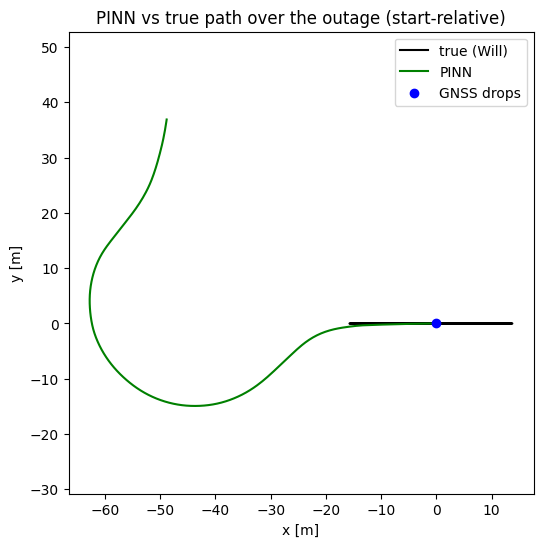

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.plot(xg, yg, 'k', label='true (Will)')
plt.plot(xp, yp, 'g', label='PINN')
plt.scatter([0], [0], c='b', zorder=5, label='GNSS drops')
plt.axis('equal'); plt.legend(); plt.xlabel('x [m]'); plt.ylabel('y [m]')
plt.title('PINN vs true path over the outage (start-relative)')
plt.show()


In [20]:
print('truth endpoint over outage (relative):', round(xg[-1],1), round(yg[-1],1))

truth endpoint over outage (relative): 1.7 0.0
